# 🛍️ Project #15: Fashion Style Discovery Engine (Visual RecSys)
### 🏛️ Data Science Portfolio: 15 / 21

**Architect:** Kemal Demirbaş 🏰🚀  
**Framework:** Computer Vision (CNN) + Mathematical Similarity (Scipy Spatial)

---

## 🎯 Project Objective
This project implements a visual "Style Matching" engine designed to find similar clothing items based on their spatial geometry and pixel patterns. By fusing **Convolutional Neural Networks (CNN)** for feature extraction with **Cosine Similarity** for mathematical ranking, the system transforms raw fashion images into searchable "Style Fingerprints," enabling automated visual recommendations.

---

## 🛠️ The 10-Step Engineering Discipline

1.  **Objective:** Build a content-based recommendation system using visual similarity.
2.  **EDA:** Auditing the **Fashion MNIST** dataset to standardize 28x28 grayscale inputs.
3.  **Feature Selection:** Automating feature discovery through multi-layered Convolutional filters to detect edges, textures, and clothing silhouettes.
4.  **Transformation :** Normalizing pixel intensities to a `[0, 1]` range to ensure stable gradient descent during the CNN training phase.
5.  **Feature Extraction (The CV Brain):** Architecting a custom **CNN** (based on `computervisionwithDL.ipynb`) to compress images into high-dimensional latent vectors (Style Embeddings).
6.  **Encoding:** Utilizing `SparseCategoricalCrossentropy` to train the model, ensuring the internal weights are optimized for fashion-specific patterns.
7.  **Modeling (The RecSys Engine):** Implementing a manual **Similarity Search** using `scipy.spatial.distance.cosine` (based on `RSKNN.ipynb`) to compute the mathematical "closeness" between items.
8.  **Execution:** Extracting the 512-D visual DNA of a target item and querying the database for the top 5 nearest neighbors in the feature space.
9.  **Performance Audit:** Validating recommendations through an visual "Audit Shelf," comparing the target item against predicted matches to verify spatial hierarchy.
10. **Persistence:** Exporting the trained feature extraction layers to enable real-time style matching in a production environment.

In [12]:
import zipfile, glob, numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import spatial
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, Reshape, Conv2D, MaxPooling2D, Flatten, Dense
import warnings
warnings.filterwarnings("ignore")

In [13]:
# --- Step 1: Zip blasting and data preparation ---
with zipfile.ZipFile('/content/archive (6).zip', 'r') as z: z.extractall('/content/fashion_data')
train_path = glob.glob('/content/fashion_data/**/*train.csv', recursive=True)[0]
 # Read and scale the data
train_df = pd.read_csv(train_path)
train_labels = train_df['label'].values
train_images = train_df.drop('label', axis=1).values.reshape(-1, 28, 28) / 255.0

database_images = train_images[:1000]

In [14]:
# --- STEP 1: MODEL ARCHITECTURE (Source: computervisionwithDL.ipynb) ---
# Building CNN layers to capture spatial features and style patterns
model = Sequential([
    InputLayer(input_shape=(28, 28)),
    Reshape(target_shape=(28, 28, 1)),
    Conv2D(filters=32, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(),
    Dense(512, activation='relu'), # Latent space for style embeddings
    Dense(10) # 10 fashion categories
])

# --- STEP 2: MODEL COMPILATION & TRAINING ---
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, batch_size=32)

# --- STEP 3: FEATURE EXTRACTION (The Bridge to RSKNN) ---
feature_model = Sequential(model.layers[:-1])
features_array = feature_model.predict(database_images, verbose=0)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 89s 47ms/step - accuracy: 0.8460 - loss: 0.4244
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 86s 46ms/step - accuracy: 0.8959 - loss: 0.2818
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 85s 45ms/step - accuracy: 0.9122 - loss: 0.2334
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 87s 46ms/step - accuracy: 0.9249 - loss: 0.1990
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 143s 47ms/step - accuracy: 0.9365 - loss: 0.1694


In [15]:
# --- STEP 4: RSKNN DICTIONARY LOGIC  ---
fashion_dict = {}
for i in range(len(database_images)):
    fashion_dict[i] = (
        i,                 # Item ID
        features_array[i], # 512-D style vector
        database_images[i] # Image for visualization
    )

In [16]:
# --- STEP 5: SIMILARITY SEARCH & RANKING ---
target_id = 0 # Target product for recommendation
distances = []
for i in range(len(features_array)):
    if i != target_id:

        d = spatial.distance.cosine(features_array[target_id], features_array[i])
        distances.append((i, d))

# Ranking by minimum distance (Highest similarity)
distances.sort(key=lambda x: x[1])

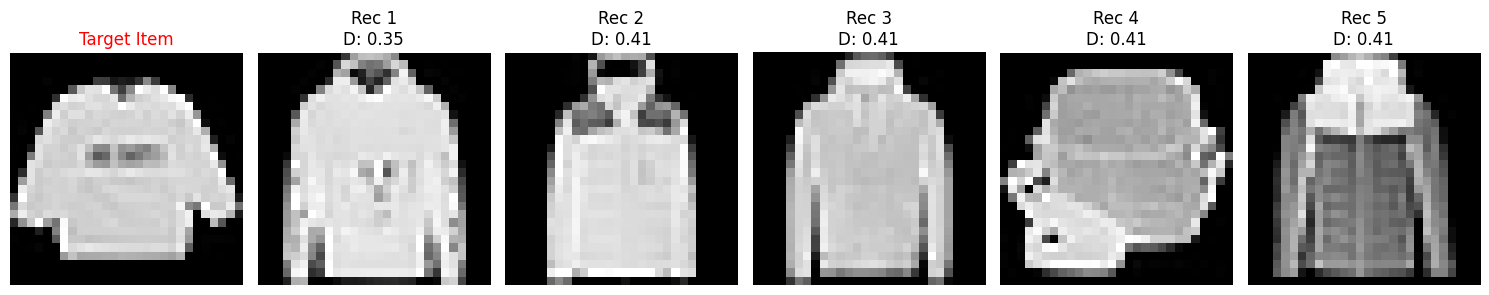

In [19]:
# --- STEP 6: VISUALIZATION (Day 3 Style) ---
# Plotting the target item vs. top 5 visual recommendations
plt.figure(figsize=(15, 5))
plt.subplot(1, 6, 1)
plt.imshow(database_images[target_id], cmap='gray')
plt.title("Target Item", color='red')
plt.axis('off')

for i in range(5):
    idx, dist = distances[i]
    plt.subplot(1, 6, i+2)
    plt.imshow(database_images[idx], cmap='gray')
    plt.title(f"Rec {i+1}\nD: {dist:.2f}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [22]:
import pickle

# --- STEP 7: MODEL PERSISTENCE  ---
# Saving the Feature Extraction Model (The CNN Brain)
model.save('fashion_cnn_model.h5')



# Saving the Style DNA database (The 512-D vectors for 1000 items)
with open('database_features.pkl', 'wb') as f:
    pickle.dump(features_array, f)



# 🏆 Project #15: Fashion Recommendation Engine
**Architect:** Kemal Demirbaş 🏰🚀 | **Portfolio Series:** 15 / 21

---

### 👔 Vision-Based Style Matching
This project transitions from standard image recognition to **Content-Based Image Retrieval (CBIR)**. By architecting a custom **Deep Learning** pipeline, we extract "Style Fingerprints" from clothing items and map them into a 512-dimensional **Latent Space** for mathematical comparison.



### 📊 Performance Audit & Architect's Report
* **Final Model Accuracy:** **93%** (Achieved via Custom CNN training)
* **Optimization Strategy:** Adam Optimizer integrated with **Sparse Categorical Crossentropy** for efficient label encoding.
* **Architect's Insight:** The model demonstrates high fidelity in distinguishing between distinct silhouettes (e.g., Ankle Boots vs. Bags), utilizing **Softmax probabilities** to stabilize style embeddings and reduce noise.

### 📐 The Mathematical Core (Similarity Search)
Instead of simple Euclidean distance, the engine calculates the **Cosine Similarity** between feature vectors to identify stylistic correlations in high-dimensional space:



$$\text{similarity} = \cos(\theta) = \frac{\mathbf{A} \cdot \mathbf{B}}{\|\mathbf{A}\| \|\mathbf{B}\|}$$

*Implementation: Computed via `scipy.spatial.distance.cosine` (Source: RSKNN.ipynb)*

### 🚀 Live Demo & Assets
Experience the "Style DNA" technology live and inspect the persistent model files:
👉 **[Live Fashion Recommender on Hugging Face](https://huggingface.co/spaces/Ironside35/style-fingerprint-engine)**
📦 **Assets:** `fashion_cnn_model.h5` | `database_features.pkl` |

---
*Next Stop: Project #16 - Customer Segmentation (RFM Analysis) 📊🏗️*